In [29]:
# Import all required libraries
import pandas as pd
import numpy as np
import pingouin as pg
from pathlib import Path
from glob import glob
from scipy import stats
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import os.path as op
import re

In [30]:
# Setup directories and plotting theme
data_dir = "./dset"
raw_annot_dir = op.join(data_dir, "annotations")
deriv_dir = op.join(data_dir, "derivatives")

# # Create directories
# OUT_DIR.mkdir(parents=True, exist_ok=True)
# FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Configure plotting theme
sns.set_theme(style="darkgrid")

# Define colors for consistent plotting
colors = ['#CF9397', "#606933", '#E5D28E', '#715958', '#AC9B74', '#8c564b', '#e377c2', '#BCB5BB']

In [39]:
episode_numbers = [1, 2, 3, 4]

run_numbers = range(0, 8)

episode_csvs = {}

for ep_num in episode_numbers:
    episode_key = f"S01E{ep_num:02d}"
    episode_dir = op.join(raw_annot_dir, episode_key)

    run_csvs = {}
    for i in run_numbers:
        run_key = f"R0{i}"
        csv_pattern = op.join(episode_dir, f"{episode_key}{run_key}*.csv")
        csv_files = sorted(glob(csv_pattern))
        if csv_files:
            run_csvs[run_key] = csv_files

    episode_csvs[episode_key] = run_csvs

    print(f"{episode_key}: {len(run_csvs)} runs with CSVs")
    for run_key, files in run_csvs.items():
        print(f"  {run_key}: {len(files)} CSV files")
        for file_path in files:
            rater_df = pd.read_csv(file_path)
            print(f"    {op.basename(file_path)} -> {rater_df.shape}")
            
    print()

S01E01: 6 runs with CSVs
  R01: 4 CSV files
    S01E01R01_002.csv -> (334, 3)
    S01E01R01_003.csv -> (334, 3)
    S01E01R01_005.csv -> (334, 3)
    S01E01R01_008.csv -> (334, 3)
  R02: 5 CSV files
    S01E01R02_001.csv -> (276, 3)
    S01E01R02_002.csv -> (276, 3)
    S01E01R02_003.csv -> (276, 3)
    S01E01R02_004.csv -> (276, 3)
    S01E01R02_008.csv -> (276, 3)
  R03: 3 CSV files
    S01E01R03_004.csv -> (275, 3)
    S01E01R03_005.csv -> (275, 3)
    S01E01R03_006.csv -> (275, 3)
  R04: 2 CSV files
    S01E01R04_001.csv -> (286, 3)
    S01E01R04_008.csv -> (286, 3)
  R05: 4 CSV files
    S01E01R05_003.csv -> (312, 3)
    S01E01R05_005.csv -> (312, 3)
    S01E01R05_006.csv -> (312, 3)
    S01E01R05_008.csv -> (312, 3)
  R06: 4 CSV files
    S01E01R06_003.csv -> (333, 3)
    S01E01R06_005.csv -> (333, 3)
    S01E01R06_006.csv -> (333, 3)
    S01E01R06_008.csv -> (333, 3)

S01E02: 7 runs with CSVs
  R01: 3 CSV files
    S01E02R01_004.csv -> (313, 3)
    S01E02R01_007.csv -> (313, 3)


S01E01 R01: 4 rater file(s)


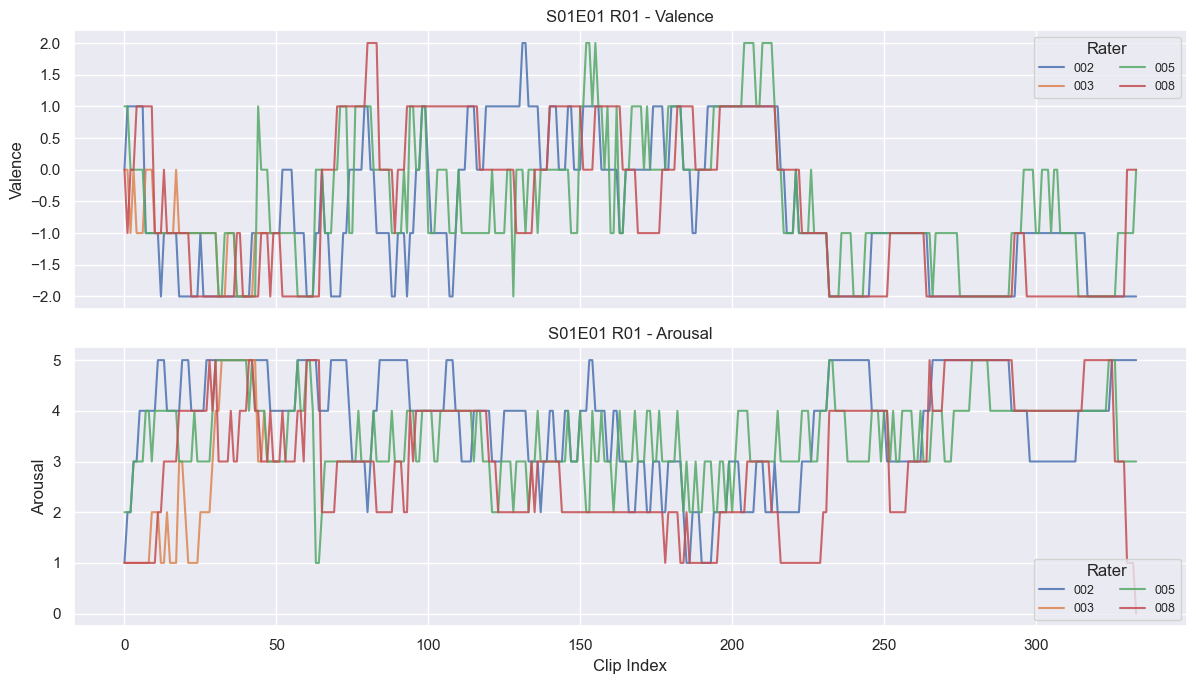

In [42]:
# Plot all raters for one run on the same valence/arousal figure
episode_to_plot = "S01E01"
run_to_plot = "R01"

run_files = episode_csvs.get(episode_to_plot, {}).get(run_to_plot, [])
print(f"{episode_to_plot} {run_to_plot}: {len(run_files)} rater file(s)")

if not run_files:
    print("No files found for this episode/run.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    for file_path in run_files:
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        val_col = col_lookup.get("valence")
        aro_col = col_lookup.get("arousal")

        if val_col is None or aro_col is None:
            continue

        filename = op.basename(file_path)
        rater_label = filename.split("_")[-1].replace(".csv", "")

        axes[0].plot(df[val_col].to_numpy(), label=rater_label, alpha=0.85)
        axes[1].plot(df[aro_col].to_numpy(), label=rater_label, alpha=0.85)

    axes[0].set_title(f"{episode_to_plot} {run_to_plot} - Valence")
    axes[0].set_ylabel("Valence")
    axes[0].legend(title="Rater", ncol=2, fontsize=9)

    axes[1].set_title(f"{episode_to_plot} {run_to_plot} - Arousal")
    axes[1].set_ylabel("Arousal")
    axes[1].set_xlabel("Clip Index")
    axes[1].legend(title="Rater", ncol=2, fontsize=9)

    plt.tight_layout()
    plt.show()

S01E01 R04: 2 rater file(s)


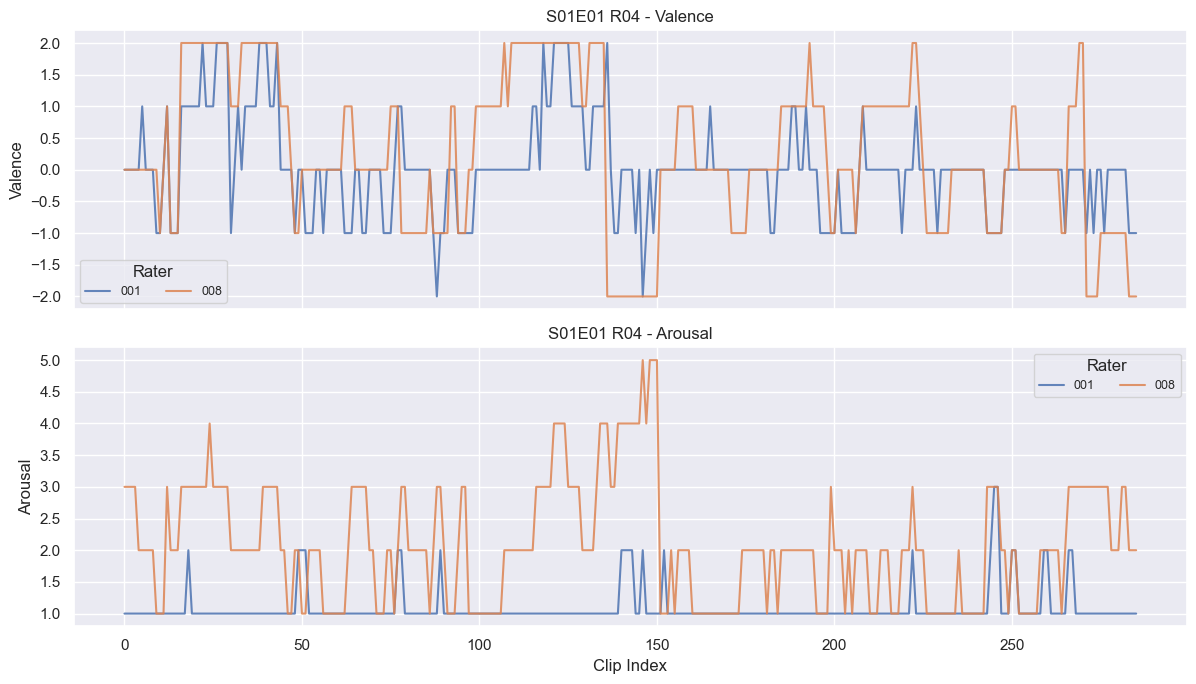

In [41]:
# Plot all raters for one run on the same valence/arousal figure
episode_to_plots = ["S01E01"]
run_to_plots = ["R04"]

for episode_to_plot, run_to_plot in zip(episode_to_plots,run_to_plots):
    run_files = episode_csvs.get(episode_to_plot, {}).get(run_to_plot, [])
    print(f"{episode_to_plot} {run_to_plot}: {len(run_files)} rater file(s)")

    if not run_files:
        print("No files found for this episode/run.")
    else:
        fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

        for file_path in run_files:
            df = pd.read_csv(file_path)
            col_lookup = {c.lower(): c for c in df.columns}
            val_col = col_lookup.get("valence")
            aro_col = col_lookup.get("arousal")

            if val_col is None or aro_col is None:
                continue

            filename = op.basename(file_path)
            rater_label = filename.split("_")[-1].replace(".csv", "")

            axes[0].plot(df[val_col].to_numpy(), label=rater_label, alpha=0.85)
            axes[1].plot(df[aro_col].to_numpy(), label=rater_label, alpha=0.85)

        axes[0].set_title(f"{episode_to_plot} {run_to_plot} - Valence")
        axes[0].set_ylabel("Valence")
        axes[0].legend(title="Rater", ncol=2, fontsize=9)

        axes[1].set_title(f"{episode_to_plot} {run_to_plot} - Arousal")
        axes[1].set_ylabel("Arousal")
        axes[1].set_xlabel("Clip Index")
        axes[1].legend(title="Rater", ncol=2, fontsize=9)

        plt.tight_layout()
        plt.show()